In [4]:
# Cell 1: Importing necessary libraries
import os
import re
import cv2
import numpy as np
from glob import glob
from pdf2image import convert_from_path
from matplotlib import pyplot as plt

# Cell 2: Setting up directories and parameters
DOCS_DIR = "docs"
EXPORT_DIR = "export"
os.makedirs(EXPORT_DIR, exist_ok=True)


In [35]:
# Processing Parameters
LINES_PER_SEGMENT = 5        # Target ~5 lines per segment
MAX_ANGLE = 45               # Maximum angle to consider for deskewing
MORPH_SIZE_FOR_LINES = (25, 1)# Kernel size for morphological operations
MIN_PAGE_AREA = 50000        # Minimum area to consider a detected block as a page

# Deskewing Refinement Parameters
CLOSING_KERNEL_SIZE = (25, 1) # Kernel size for morphological closing
CONTOUR_AREA_THRESHOLD = 0.5   # Minimum area ratio for contour filtering
MIN_LINE_LENGTH = 50           # Minimum length of lines to consider

In [36]:
def natural_sort_key(s):
    base = os.path.basename(s)
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', base)]
def deskew_image(img):
    """
    Deskew an image based on the dominant angle of text lines.
    """
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply threshold to create a binary image
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Detect edges
    edges = cv2.Canny(bw, 50, 150, apertureSize=3)

    # Use Hough Line Transform to detect lines
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)

    if lines is None:
        print("No lines detected. Image might not require deskewing.")
        return img  # Return the original image if no lines are detected

    # Calculate angles of detected lines
    angles = []
    for line in lines:
        for rho, theta in line:
            angle = (theta * 180 / np.pi) - 90  # Convert angle to degrees
            if abs(angle) < MAX_ANGLE:  # Filter out steep angles
                angles.append(angle)

    if not angles:
        print("No suitable angles detected for deskewing.")
        return img

    # Compute the median angle
    median_angle = np.median(angles)
    print(f"Median angle for deskewing: {median_angle} degrees")

    # Rotate the image to deskew
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, median_angle, 1.0)
    deskewed_img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    return deskewed_img


def detect_pages(img):
    """
    Detect "scanned pages" within a PDF page image using connected components analysis.
    Steps:
    1. Convert to grayscale, threshold.
    2. Morphological closing to merge text into large blocks.
    3. Find connected components.
    4. Filter large blocks as pages.
    5. If a block is not roughly rectangular, approximate polygon and try perspective correction.
    """

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Use adaptive threshold for possibly uneven lighting
    bw = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 35, 15)
    inv = cv2.bitwise_not(bw)

    # Morphological close to get bigger blocks (merge text into paragraphs)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15,15))
    closed = cv2.morphologyEx(inv, cv2.MORPH_CLOSE, kernel)

    # Connected components
    # We want to find large blocks that could represent a page
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed, connectivity=8)
    pages = []
    h, w = closed.shape
    for i in range(1, num_labels):
        x, y, w_, h_ = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        if area > MIN_PAGE_AREA and w_ > 100 and h_ > 100:
            candidate = img[y:y+h_, x:x+w_]
            # Attempt a slight perspective correction if needed
            # We could try edge detection to find a quadrilateral
            candidate = perspective_correction(candidate)
            candidate = deskew_image(candidate)
            if candidate is not None and candidate.size > 0:
                pages.append(candidate)

    # If no pages found, fallback to using the entire image as one page
    if not pages:
        full = deskew_image(img)
        if full is not None and full.size > 0:
            pages = [full]

    return pages

def perspective_correction(img):
    """
    Attempt a rough perspective correction by detecting edges and approximating a polygon.
    If fail, return the image as is.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 200)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    best_approx = None
    best_area = 0
    h, w = gray.shape
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 0.5 * w * h:  # We want a contour that covers a large fraction of the image
            continue
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02*peri, True)
        if len(approx) == 4 and area > best_area:
            best_area = area
            best_approx = approx

    if best_approx is not None:
        pts = best_approx.reshape(4,2).astype(np.float32)
        pts = order_points(pts)
        (tl, tr, br, bl) = pts

        widthA = np.linalg.norm(br - bl)
        widthB = np.linalg.norm(tr - tl)
        maxWidth = int(max(widthA, widthB))

        heightA = np.linalg.norm(tr - br)
        heightB = np.linalg.norm(tl - bl)
        maxHeight = int(max(heightA, heightB))

        dst = np.array([
            [0, 0],
            [maxWidth-1, 0],
            [maxWidth-1, maxHeight-1],
            [0, maxHeight-1]], dtype="float32")

        M = cv2.getPerspectiveTransform(pts, dst)
        warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))
        return warped
    return img

def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def find_text_lines(img):
    """
    Find horizontal text lines by linking characters:
    1. Binarize & invert: text = white
    2. Morphological dilation horizontally to connect characters into lines.
    3. Find the y-coordinates of each line by projection.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Binarize
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    inv = cv2.bitwise_not(th)

    # Dilate horizontally to connect text into lines
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, MORPH_SIZE_FOR_LINES)
    dil = cv2.dilate(inv, kernel, iterations=1)

    # Projection
    h, w = dil.shape
    projection = np.sum(dil==255, axis=1)
    # A line of text should have a significant number of white pixels
    mean_val = np.mean(projection)
    line_indices = []
    # Identify rows that have more than mean_val/2 pixels as potential line centers
    # Then group consecutive rows together as a single line region.
    is_line = projection > (mean_val/2)
    start = None
    for i, val in enumerate(is_line):
        if val and start is None:
            start = i
        elif not val and start is not None:
            end = i
            line_indices.append((start, end))
            start = None
    if start is not None:
        line_indices.append((start, h-1))

    # Get line centers as the midpoint of these indices
    line_positions = []
    for (st, en) in line_indices:
        line_positions.append((st+en)//2)

    return line_positions

def segment_lines_into_groups(img, line_positions, pdf_name, scan_page_number):
    """
    Group lines into segments. Each segment will contain approximately LINES_PER_SEGMENT lines.
    We'll create segments by cutting between groups of lines rather than at arbitrary heights.
    """
    # If no lines, just save the whole image as one segment
    if not line_positions:
        out_name = f"{pdf_name}_page{scan_page_number}_segment1.png"
        out_path = os.path.join(EXPORT_DIR, out_name)
        if img.size > 0:
            cv2.imwrite(out_path, img)
            print(f"Exported: {out_path}")
        return

    # Sort line positions
    line_positions = sorted(line_positions)
    h, w = img.shape[:2]

    # We'll form segments by taking approximately LINES_PER_SEGMENT lines at a time
    segments = []
    i = 0
    while i < len(line_positions):
        # Start line
        start_line = line_positions[i]
        # End line (after LINES_PER_SEGMENT lines or the last line)
        end_idx = min(i+LINES_PER_SEGMENT-1, len(line_positions)-1)
        end_line = line_positions[end_idx]

        # Add a small margin above the start_line and below the end_line
        top = max(start_line - 20, 0)
        bottom = min(end_line + 20, h)
        segments.append((top, bottom))
        i = end_idx + 1

    # If for some reason we got no segments, fallback to entire image
    if not segments:
        segments = [(0,h)]

    # Export segments
    for seg_i, (top, bottom) in enumerate(segments, start=1):
        if bottom > top:
            segment_img = img[top:bottom, :]
            if segment_img.size > 0:
                out_name = f"{pdf_name}_page{scan_page_number}_segment{seg_i}.png"
                out_path = os.path.join(EXPORT_DIR, out_name)
                cv2.imwrite(out_path, segment_img)
                print(f"Exported: {out_path}")
        else:
            print(f"Warning: invalid segment boundaries ({top}, {bottom}) for {pdf_name}_page{scan_page_number}_segment{seg_i}")

def process_pdf(pdf_path):
    pdf_name = os.path.splitext(os.path.basename(pdf_path))[0]
    pages = convert_from_path(pdf_path, dpi=300)

    for page_index, page_image in enumerate(pages, start=1):
        page_cv = cv2.cvtColor(np.array(page_image), cv2.COLOR_RGB2BGR)
        scanned_pages = detect_pages(page_cv)
        if not scanned_pages:
            # fallback to the entire page if no sub-pages detected
            scanned_pages = [deskew_image(page_cv)]

        for sp_i, sp in enumerate(scanned_pages, start=1):
            if sp is not None and sp.size > 0:
                line_positions = find_text_lines(sp)
                segment_lines_into_groups(sp, line_positions, pdf_name + f"_page{page_index}", sp_i)
            else:
                print(f"Scanned page {sp_i} in {pdf_name}_page{page_index} is empty or invalid. Skipping.")

In [37]:
# Cell 4: Load a sample PDF
sample_pdf_path = os.path.join(DOCS_DIR, "2HEALEYnHIRST042112P10001.pdf")  # Replace with your test PDF name
pages = convert_from_path(sample_pdf_path, dpi=300)
print(f"Loaded {len(pages)} pages from {sample_pdf_path}.")

Loaded 1 pages from docs/2HEALEYnHIRST042112P10001.pdf.


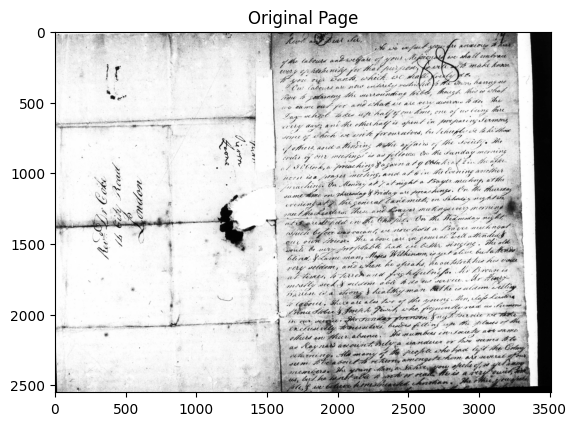

In [38]:
# Cell 5: Process the first page of the PDF
page_image = pages[0]
page_cv = cv2.cvtColor(np.array(page_image), cv2.COLOR_RGB2BGR)
plt.imshow(cv2.cvtColor(page_cv, cv2.COLOR_BGR2RGB))
plt.title("Original Page")
plt.show()

# Cell 6: Deskew the page

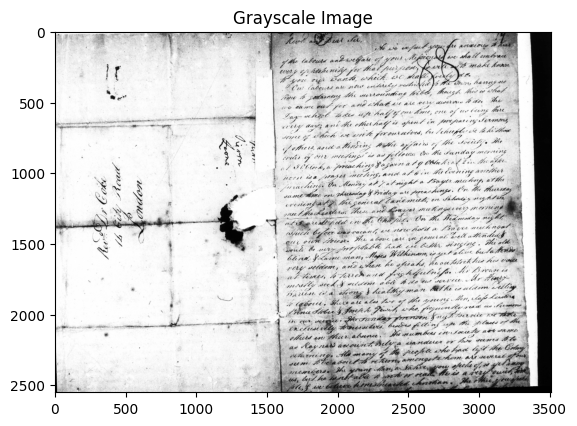

In [39]:
# Convert to grayscale
gray = cv2.cvtColor(page_cv, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.show()


In [43]:
_, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
# Alternative: Use adaptive thresholding for uneven lighting
bw = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                           cv2.THRESH_BINARY_INV, 35, 15)

plt.imshow(bw, cmap='gray')
plt.title("Binary Threshold Image")
plt.show()

# Cell 6: Apply adaptive thresholding
adaptive_bw = cv2.adaptiveThreshold(
    gray, 
    255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 
    35, 
    15
)
plt.figure(figsize=(10, 10))
plt.imshow(adaptive_bw, cmap='gray')
plt.title("Adaptive Threshold Image")
plt.axis('off')
plt.show()



SyntaxError: invalid syntax (1841004652.py, line 10)

In [33]:
# Detect edges using Canny edge detector
# kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
# bw_cleaned = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel)
# edges = cv2.Canny(bw_cleaned, 50, 150, apertureSize=3)
# plt.imshow(edges, cmap='gray')
# plt.title("Edges Detected")
# plt.show()

# Cell 7: Apply morphological closing to connect text lines
closing_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, CLOSING_KERNEL_SIZE)
closed = cv2.morphologyEx(adaptive_bw, cv2.MORPH_CLOSE, closing_kernel)
plt.figure(figsize=(10, 10))
plt.imshow(closed, cmap='gray')
plt.title("Morphological Closing")
plt.axis('off')
plt.show()



NameError: name 'CLOSING_KERNEL_SIZE' is not defined

In [34]:
# # Use Hough Transform to detect lines
# lines = cv2.HoughLines(edges, 1, np.pi / 180, 250)

# # Draw detected lines on a copy of the original image for visualization
# line_image = page_cv.copy()
# if lines is not None:
#     for line in lines:
#         for rho, theta in line:
#             a = np.cos(theta)
#             b = np.sin(theta)
#             x0 = a * rho
#             y0 = b * rho
#             x1 = int(x0 + 1000 * (-b))
#             y1 = int(y0 + 1000 * a)
#             x2 = int(x0 - 1000 * (-b))
#             y2 = int(y0 - 1000 * a)
#             cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# plt.imshow(cv2.cvtColor(line_image, cv2.COLOR_BGR2RGB))
# plt.title("Detected Lines")
# plt.show()


# Cell 8: Find and filter contours
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filtered_contours_img = original_image.copy()
filtered_contours = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    area = cv2.contourArea(cnt)
    if area > MIN_PAGE_AREA and w > 100 and h > 100:
        cv2.rectangle(filtered_contours_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        filtered_contours.append(cnt)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(filtered_contours_img, cv2.COLOR_BGR2RGB))
plt.title("Filtered Contours (Potential Pages)")
plt.axis('off')
plt.show()

print(f"Total filtered contours: {len(filtered_contours)}")


NameError: name 'closed' is not defined

In [30]:
# Cell 9: Apply perspective correction to filtered contours
# For each filtered contour, apply perspective correction
corrected_images = []
for idx, cnt in enumerate(filtered_contours, start=1):
    x, y, w, h = cv2.boundingRect(cnt)
    candidate = original_image[y:y+h, x:x+w]
    corrected = perspective_correction(candidate)
    corrected_images.append(corrected)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
    plt.title(f"Perspective Corrected Image {idx}")
    plt.axis('off')
    plt.show()


Median angle for deskewing: -2.0000076293945312 degrees
